In [1]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, recall_score, precision_score,
    precision_recall_curve, average_precision_score
)
import xgboost as xgb
import lightgbm as lgb
import shap
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import platform
SEED = 42
np.random.seed(SEED)
print("✅ 모델링 라이브러리 로드 완료")

✅ 모델링 라이브러리 로드 완료


## STEP 1. 피처 및 타겟 정의

In [2]:
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
type1_df = pd.read_csv('../../data/df_final_Type1.csv')
type1_df['Pressure_Diff_ratio'] = type1_df['Casting_Pressure'] / type1_df['Cylinder_Pressure']
FEATURES = [
    'Velocity_1', 
    'Velocity_2', 
    'Velocity_3',
    'High_Velocity', 
    'Rapid_Rise_Time',
    'Biscuit_Thickness', 
    'Clamping_Force', 
    'Cycle_Time',
    'Pressure_Rise_Time', 
    'Casting_Pressure',
    'Cylinder_Pressure', 
    'Spray_Time', 
    'Spray_1_Time',
    'Spray_2_Time', 
    'Melting_Furnace_Temp', 
    'Air_Pressure', 
    'Coolant_Temp',
    'Coolant_Pressure', 
    'Factory_Temp', 
    'Factory_Humidity', 
    # 'Defect_Status' → 타겟 변수이므로 제거 (데이터 누수)
    # 'Defect_Type'   → 타겟과 직결된 범주형 변수이므로 제거 (데이터 누수)
    'Pressure_Diff_ratio'
]

X = type1_df[FEATURES].copy()
y = type1_df['Defect_Status'].copy()

print(f"📌 피처 수: {len(FEATURES)}개")
print(f"📌 타겟 분포 → 양품: {(y==0).sum()} / 불량: {(y==1).sum()} ({y.mean()*100:.1f}%)")

📌 피처 수: 21개
📌 타겟 분포 → 양품: 2075 / 불량: 576 (21.7%)


## STEP 2. Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

pos_weight = (y_train==0).sum() / (y_train==1).sum()

print(f"훈련셋: {X_train.shape[0]}행  |  테스트셋: {X_test.shape[0]}행")
print(f"훈련셋 불량률: {y_train.mean()*100:.1f}%  |  테스트셋 불량률: {y_test.mean()*100:.1f}%")
print(f"scale_pos_weight: {pos_weight:.2f}")

훈련셋: 2120행  |  테스트셋: 531행
훈련셋 불량률: 21.7%  |  테스트셋 불량률: 21.7%
scale_pos_weight: 3.60


In [4]:
from sklearn.ensemble import IsolationForest

# 수치형 컬럼만 선택
X_train_num = X_train.select_dtypes(include=['int64', 'float64'])
X_test_num = X_test.select_dtypes(include=['int64', 'float64'])

iso = IsolationForest(contamination=0.01, random_state=SEED)
iso.fit(X_train_num)
train_anomaly = iso.predict(X_train_num)
test_anomaly = iso.predict(X_test_num)

print(f"훈련셋 이상치: {(train_anomaly == -1).sum()}건 ({(train_anomaly == -1).mean()*100:.1f}%)")
print(f"테스트셋 이상치: {(test_anomaly == -1).sum()}건 ({(test_anomaly == -1).mean()*100:.1f}%)")

X_train_iso = X_train_num[train_anomaly == 1]
y_train_iso = y_train[train_anomaly == 1]
print(f"\nIsolation Forest 후 훈련셋: {X_train_iso.shape[0]}행")
print(f"불량률: {y_train_iso.mean()*100:.1f}%")

훈련셋 이상치: 21건 (1.0%)
테스트셋 이상치: 4건 (0.8%)

Isolation Forest 후 훈련셋: 2099행
불량률: 22.0%


## STEP 3. 베이스라인 모델 비교

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def find_best_threshold_constrained(y_true, y_prob, target_recall=0.80,
                                    thr_min=0.05, thr_max=0.95, step=0.01):
    thresholds = np.arange(thr_min, thr_max + 1e-9, step)
    best, best_any = None, None
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        r  = recall_score(y_true, y_pred, zero_division=0)
        p  = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        row = (thr, r, p, f1)
        if best_any is None or f1 > best_any[3]: best_any = row
        if r >= target_recall:
            if best is None or f1 > best[3]: best = row
    if best:
        thr,r,p,f1 = best; ok = True
    else:
        thr,r,p,f1 = best_any; ok = False
    return thr, r, p, f1, ok

# XGBoost용 원-핫
X_train_xgb = pd.get_dummies(X_train)
X_test_xgb  = pd.get_dummies(X_test).reindex(columns=X_train_xgb.columns, fill_value=0)

baseline_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        scale_pos_weight=pos_weight, n_estimators=200,
        random_state=SEED, eval_metric='logloss', verbosity=0),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        scale_pos_weight=pos_weight, random_state=SEED, verbose=-1),
}

baseline_results = []
for name, model in baseline_models.items():
    if name == 'XGBoost':
        model.fit(X_train_xgb, y_train)
        yp = model.predict_proba(X_test_xgb)[:,1]
    else:
        model.fit(X_train, y_train)
        yp = model.predict_proba(X_test)[:,1]

    thr,r,p,f1,ok = find_best_threshold_constrained(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    baseline_results.append({
        '모델': name, '임계값': round(thr,2),
        'Recall': round(r,4), 'Precision': round(p,4),
        'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4),
        'Recall≥0.80': '✅' if ok else '❌'
    })
    print(f"  ✅ {name} 완료 | thr={thr:.2f} | Recall={r:.3f} | F1={f1:.3f}")

result_df = pd.DataFrame(baseline_results).sort_values('F1-Score', ascending=False)
display(result_df)

  ✅ Logistic Regression 완료 | thr=0.44 | Recall=0.835 | F1=0.518
  ✅ Random Forest 완료 | thr=0.15 | Recall=0.800 | F1=0.483
  ✅ XGBoost 완료 | thr=0.12 | Recall=0.643 | F1=0.493
  ✅ LightGBM 완료 | thr=0.06 | Recall=0.687 | F1=0.506


,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Logistic Regression,0.44,0.8348,0.3750,0.5175,0.7897,✅
3,LightGBM,0.06,0.6870,0.4010,0.5064,0.7681,❌
2,XGBoost,0.12,0.6435,0.4000,0.4933,0.7496,❌
1,Random Forest,0.15,0.8000,0.3459,0.4829,0.7624,✅


In [6]:
from imblearn.over_sampling import SMOTE

# -------------------------------------------
# SMOTE 적용
# -------------------------------------------
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"SMOTE 전 → 양품: {(y_train==0).sum()} / 불량: {(y_train==1).sum()}")
print(f"SMOTE 후 → 양품: {(y_train_sm==0).sum()} / 불량: {(y_train_sm==1).sum()}")

# -------------------------------------------
# SMOTE 적용 모델 비교
# -------------------------------------------
smote_results = []
for name, model in baseline_models.items():
    if name == 'XGBoost':
        model.fit(X_train_sm, y_train_sm)
        yp = model.predict_proba(X_test_xgb)[:,1]
    else:
        model.fit(X_train_sm, y_train_sm)
        yp = model.predict_proba(X_test)[:,1]

    thr,r,p,f1,ok = find_best_threshold_constrained(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    smote_results.append({
        '모델': name, '임계값': round(thr,2),
        'Recall': round(r,4), 'Precision': round(p,4),
        'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4),
        'Recall≥0.80': '✅' if ok else '❌'
    })
    print(f"  ✅ {name} 완료 | thr={thr:.2f} | Recall={r:.3f} | F1={f1:.3f}")

print("\n[ SMOTE vs 미적용 비교 ]")
display(pd.DataFrame(smote_results).sort_values('F1-Score', ascending=False))

SMOTE 전 → 양품: 1659 / 불량: 461
SMOTE 후 → 양품: 1659 / 불량: 1659
  ✅ Logistic Regression 완료 | thr=0.45 | Recall=0.809 | F1=0.511
  ✅ Random Forest 완료 | thr=0.23 | Recall=0.809 | F1=0.487
  ✅ XGBoost 완료 | thr=0.09 | Recall=0.670 | F1=0.483
  ✅ LightGBM 완료 | thr=0.16 | Recall=0.565 | F1=0.483

[ SMOTE vs 미적용 비교 ]


,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Logistic Regression,0.45,0.8087,0.3735,0.5110,0.7762,✅
1,Random Forest,0.23,0.8087,0.3483,0.4869,0.7541,✅
3,LightGBM,0.16,0.5652,0.4221,0.4833,0.7556,❌
2,XGBoost,0.09,0.6696,0.3775,0.4828,0.7255,❌


In [7]:
# -------------------------------------------
# SMOTE sampling_strategy 비율별 실험
# 원본 불량:양품 ≈ 1:3.6  →  비율을 조금씩 올려가며 최적점 탐색
# -------------------------------------------
from imblearn.over_sampling import SMOTE

strategies = [0.3, 0.5, 0.7, 1.0]   # 불량/양품 비율 목표값
ratio_results = []

for strategy in strategies:
    smote_exp = SMOTE(sampling_strategy=strategy, random_state=SEED)
    X_sm, y_sm = smote_exp.fit_resample(X_train, y_train)
    n_neg, n_pos = (y_sm==0).sum(), (y_sm==1).sum()

    for name, model in baseline_models.items():
        # 모델 재생성 (이전 fit 상태 초기화)
        if name == 'Logistic Regression':
            m = Pipeline([
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED))
            ])
        elif name == 'Random Forest':
            m = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1)
        elif name == 'XGBoost':
            m = xgb.XGBClassifier(scale_pos_weight=pos_weight, n_estimators=200,
                                   random_state=SEED, eval_metric='logloss', verbosity=0)
        else:  # LightGBM
            m = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                                    scale_pos_weight=pos_weight, random_state=SEED, verbose=-1)

        if name == 'XGBoost':
            X_sm_xgb = pd.get_dummies(X_sm).reindex(columns=X_train_xgb.columns, fill_value=0)
            m.fit(X_sm_xgb, y_sm)
            yp = m.predict_proba(X_test_xgb)[:,1]
        else:
            m.fit(X_sm, y_sm)
            yp = m.predict_proba(X_test)[:,1]

        thr, r, p, f1, ok = find_best_threshold_constrained(y_test, yp)
        auc = roc_auc_score(y_test, yp)
        ratio_results.append({
            'strategy': strategy,
            f'양품:{n_neg} / 불량:{n_pos}': '',
            '모델': name,
            '임계값': round(thr, 2),
            'Recall': round(r, 4),
            'Precision': round(p, 4),
            'F1-Score': round(f1, 4),
            'ROC-AUC': round(auc, 4),
            'Recall≥0.80': '✅' if ok else '❌'
        })

ratio_df = pd.DataFrame(ratio_results).drop(columns=[f'양품:{n_neg} / 불량:{n_pos}'])

print("[ SMOTE sampling_strategy 비율별 비교 ]")
for s in strategies:
    sub = ratio_df[ratio_df['strategy'] == s].drop(columns='strategy')
    n_pos_s = int(round((y_train==0).sum() * s))
    print(f"\n▶ strategy={s}  (불량 목표: ~{n_pos_s}건, 양품:불량 ≈ 1:{s})")
    display(sub.sort_values('F1-Score', ascending=False).reset_index(drop=True))

[ SMOTE sampling_strategy 비율별 비교 ]

▶ strategy=0.3  (불량 목표: ~498건, 양품:불량 ≈ 1:0.3)


,양품:1659 / 불량:497,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80,양품:1659 / 불량:829,양품:1659 / 불량:1161
0,,Logistic Regression,0.44,0.8348,0.3735,0.5161,0.7878,✅,NaN,NaN
1,,Random Forest,0.15,0.8522,0.3513,0.4975,0.7650,✅,NaN,NaN
2,,LightGBM,0.05,0.6957,0.3846,0.4954,0.7675,❌,NaN,NaN
3,,XGBoost,0.05,0.7217,0.3517,0.4729,0.7361,❌,NaN,NaN



▶ strategy=0.5  (불량 목표: ~830건, 양품:불량 ≈ 1:0.5)


,양품:1659 / 불량:497,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80,양품:1659 / 불량:829,양품:1659 / 불량:1161
0,NaN,Logistic Regression,0.44,0.8000,0.3710,0.5069,0.7779,✅,,NaN
1,NaN,LightGBM,0.07,0.6435,0.3834,0.4805,0.7607,❌,,NaN
2,NaN,Random Forest,0.16,0.8522,0.3322,0.4780,0.7570,✅,,NaN
3,NaN,XGBoost,0.05,0.7652,0.3451,0.4757,0.7430,❌,,NaN



▶ strategy=0.7  (불량 목표: ~1161건, 양품:불량 ≈ 1:0.7)


,양품:1659 / 불량:497,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80,양품:1659 / 불량:829,양품:1659 / 불량:1161
0,NaN,Logistic Regression,0.45,0.8000,0.3802,0.5154,0.7775,✅,NaN,
1,NaN,LightGBM,0.06,0.7043,0.3821,0.4954,0.7507,❌,NaN,
2,NaN,Random Forest,0.18,0.8609,0.3278,0.4748,0.7626,✅,NaN,
3,NaN,XGBoost,0.08,0.6870,0.3559,0.4688,0.7258,❌,NaN,



▶ strategy=1.0  (불량 목표: ~1659건, 양품:불량 ≈ 1:1.0)


,양품:1659 / 불량:497,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80,양품:1659 / 불량:829,양품:1659 / 불량:1161
0,NaN,Logistic Regression,0.45,0.8087,0.3735,0.5110,0.7762,✅,NaN,NaN
1,NaN,Random Forest,0.23,0.8087,0.3483,0.4869,0.7541,✅,NaN,NaN
2,NaN,LightGBM,0.16,0.5652,0.4221,0.4833,0.7556,❌,NaN,NaN
3,NaN,XGBoost,0.09,0.6696,0.3775,0.4828,0.7255,❌,NaN,NaN


## STEP 4. 하이퍼파라미터 튜닝

In [8]:
from sklearn.model_selection import RandomizedSearchCV

# SMOTE 적용 데이터로 튜닝 (비율 실험 결과 → strategy=0.3 최적)
smote_tuning = SMOTE(sampling_strategy=0.3, random_state=SEED)
X_train_sm, y_train_sm = smote_tuning.fit_resample(X_train, y_train)
X_train_sm_xgb = pd.get_dummies(X_train_sm).reindex(columns=X_train_xgb.columns, fill_value=0)
print(f"튜닝용 SMOTE 후 → 양품: {(y_train_sm==0).sum()} / 불량: {(y_train_sm==1).sum()}")

# -------------------------------------------
# 1. Random Forest
# -------------------------------------------
rf_param = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
    rf_param, n_iter=30, scoring='f1', cv=5, random_state=SEED, n_jobs=-1
)
rf_search.fit(X_train_sm, y_train_sm)
best_rf = rf_search.best_estimator_
print(f"RF 최적: {rf_search.best_params_}")

# -------------------------------------------
# 2. XGBoost
# -------------------------------------------
xgb_param = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=pos_weight, random_state=SEED,
                      eval_metric='logloss', verbosity=0),
    xgb_param, n_iter=30, scoring='f1', cv=5, random_state=SEED, n_jobs=-1
)
xgb_search.fit(X_train_sm_xgb, y_train_sm)
best_xgb = xgb_search.best_estimator_
print(f"XGB 최적: {xgb_search.best_params_}")

# -------------------------------------------
# 3. LightGBM
# -------------------------------------------
lgb_param = {
    'n_estimators':  [300, 500, 700],
    'max_depth':     [5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves':    [31, 63, 127],
    'subsample':     [0.7, 0.8, 1.0],
}
lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(scale_pos_weight=pos_weight, random_state=SEED, verbose=-1),
    lgb_param, n_iter=30, scoring='f1', cv=5, random_state=SEED, n_jobs=-1
)
lgb_search.fit(X_train_sm, y_train_sm)
best_lgb = lgb_search.best_estimator_
print(f"LGB 최적: {lgb_search.best_params_}")

# -------------------------------------------
# 결과 비교
# -------------------------------------------
tuned_results = []
for name, model, X_te in [
    ('Random Forest', best_rf, X_test),
    ('XGBoost',       best_xgb, X_test_xgb),
    ('LightGBM',      best_lgb, X_test),
]:
    yp = model.predict_proba(X_te)[:,1]
    thr,r,p,f1,ok = find_best_threshold_constrained(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    tuned_results.append({
        '모델': name, '임계값': round(thr,2),
        'Recall': round(r,4), 'Precision': round(p,4),
        'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4),
        'Recall≥0.80': '✅' if ok else '❌'
    })
    print(f"  ✅ {name} | thr={thr:.2f} | Recall={r:.3f} | F1={f1:.3f}")

display(pd.DataFrame(tuned_results).sort_values('F1-Score', ascending=False))

튜닝용 SMOTE 후 → 양품: 1659 / 불량: 497
RF 최적: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
XGB 최적: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
LGB 최적: {'subsample': 0.7, 'num_leaves': 127, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01}
  ✅ Random Forest | thr=0.32 | Recall=0.835 | F1=0.504
  ✅ XGBoost | thr=0.45 | Recall=0.826 | F1=0.501
  ✅ LightGBM | thr=0.44 | Recall=0.800 | F1=0.533


,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
2,LightGBM,0.44,0.8000,0.4000,0.5333,0.7894,✅
0,Random Forest,0.32,0.8348,0.3609,0.5039,0.7895,✅
1,XGBoost,0.45,0.8261,0.3598,0.5013,0.7889,✅


## STEP 5. 최종 평가-LightGBM

  최종 모델: LightGBM (임계값 0.440)
              precision    recall  f1-score   support

          양품     0.9236    0.6683    0.7755       416
          불량     0.4000    0.8000    0.5333       115

    accuracy                         0.6968       531
   macro avg     0.6618    0.7341    0.6544       531
weighted avg     0.8102    0.6968    0.7230       531



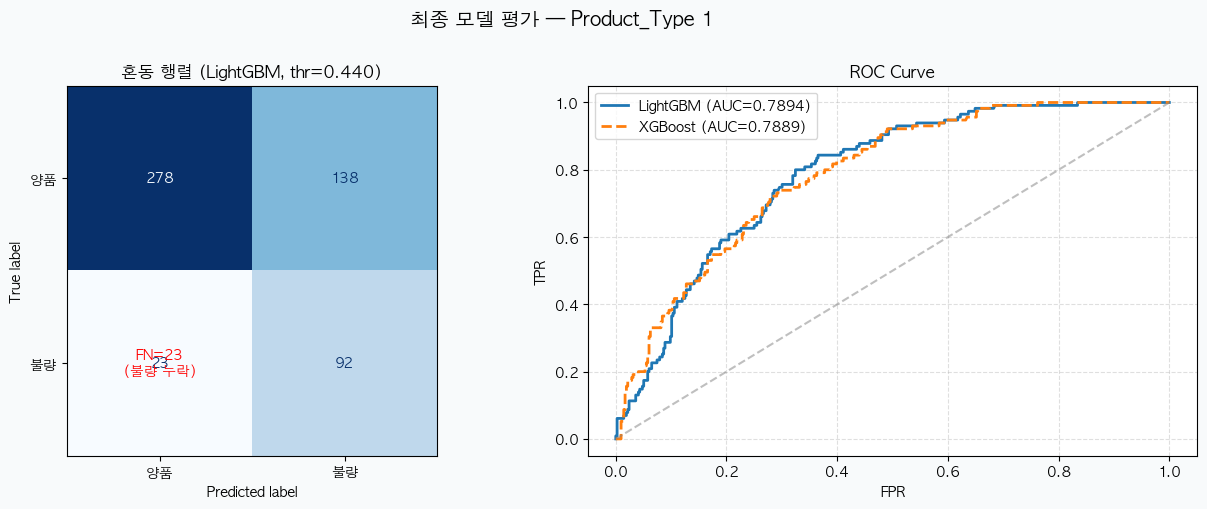

In [9]:
# LightGBM 확률값 및 최적 임계값
y_prob_lgbm = best_lgb.predict_proba(X_test)[:,1]
opt_thr_lgbm, _, _, _, _ = find_best_threshold_constrained(y_test, y_prob_lgbm)

# XGBoost 확률값
y_prob_xgb = best_xgb.predict_proba(X_test_xgb)[:,1]
y_pred_final = (y_prob_lgbm >= opt_thr_lgbm).astype(int)

print("=" * 55)
print(f"  최종 모델: LightGBM (임계값 {opt_thr_lgbm:.3f})")
print("=" * 55)
print(classification_report(y_test, y_pred_final,
                            target_names=['양품','불량'], digits=4))

# 혼동행렬 + ROC
fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_lgbm)
fpr_x, tpr_x, _ = roc_curve(y_test, y_prob_xgb)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#F8FAFB')

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=['양품','불량']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
tn,fp,fn,tp = cm.ravel()
axes[0].set_title(f'혼동 행렬 (LightGBM, thr={opt_thr_lgbm:.3f})', fontweight='bold')
axes[0].text(0, 1, f'FN={fn}\n(불량 누락)', ha='center', va='center',
             fontsize=10, color='red', fontweight='bold')

axes[1].plot(fpr_l, tpr_l, lw=2, label=f'LightGBM (AUC={roc_auc_score(y_test,y_prob_lgbm):.4f})')
axes[1].plot(fpr_x, tpr_x, lw=2, linestyle='--', label=f'XGBoost (AUC={roc_auc_score(y_test,y_prob_xgb):.4f})')
axes[1].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle('최종 모델 평가 — Product_Type 1',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## STEP 6. SHAP

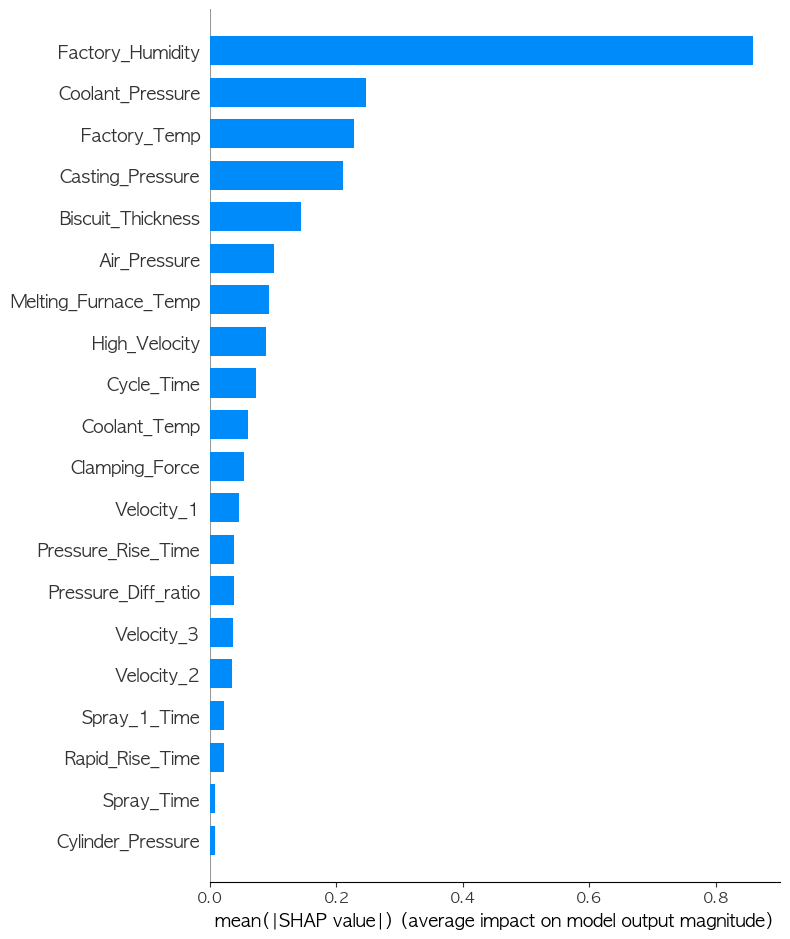

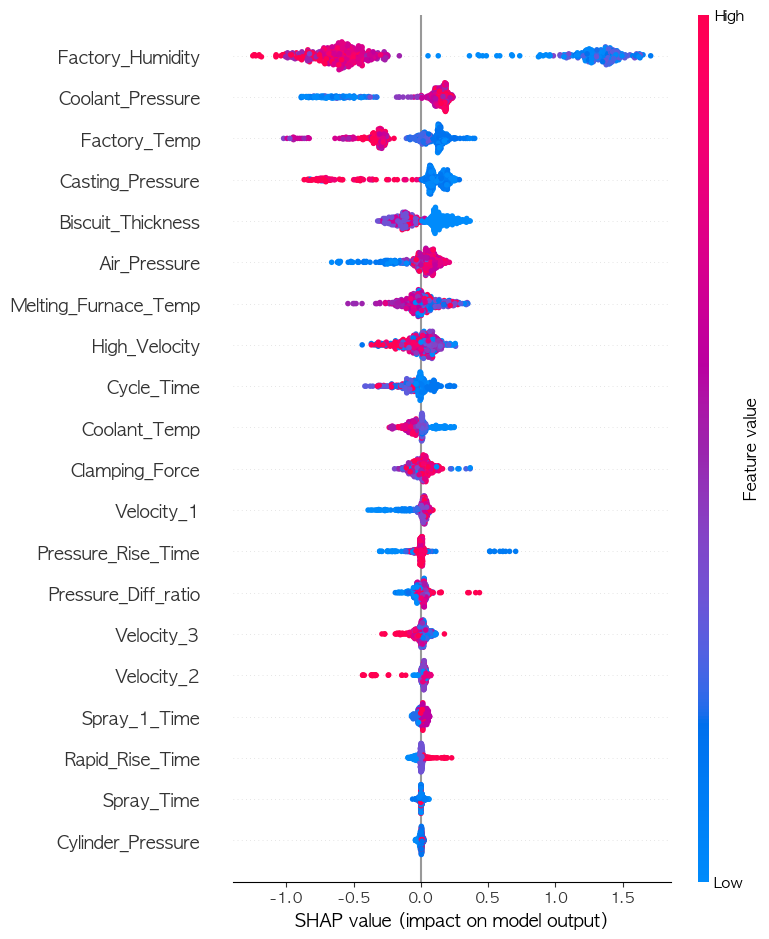

In [10]:
import shap
import warnings
warnings.filterwarnings('ignore')
# -------------------------------------------
# SHAP (LightGBM 기준)
# -------------------------------------------
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(X_test)  # 이게 빠짐

shap_values_array = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(shap_values_array, X_test, plot_type='bar', show=True)
shap.summary_plot(shap_values_array, X_test, show=True)

## STEP 7. Isolation Forest + LightGBM 2단계 파이프라인

In [11]:
from sklearn.ensemble import IsolationForest

# =======================================================
# STEP 7. Isolation Forest + LightGBM (이상치 점수 피처 추가)
#
# - 양품 데이터로만 IF 학습 → "정상 공정 패턴" 학습
# - decision_function()으로 이상치 점수 추출
#   (낮을수록 이상, 높을수록 정상)
# - 이상치 점수를 새 피처로 추가 → LightGBM 재학습
# =======================================================

# -------------------------------------------
# Stage 1: Isolation Forest (양품 데이터로만 학습)
# -------------------------------------------
X_train_normal = X_train[y_train == 0]

iso_pipe = IsolationForest(random_state=SEED)
iso_pipe.fit(X_train_normal)

# 이상치 점수 추출 (연속값: 낮을수록 이상)
X_train_if = X_train.copy()
X_test_if  = X_test.copy()

X_train_if['anomaly_score'] = iso_pipe.decision_function(X_train)
X_test_if['anomaly_score']  = iso_pipe.decision_function(X_test)

print("[ Isolation Forest 이상치 점수 통계 ]")
print(f"훈련셋 anomaly_score: mean={X_train_if['anomaly_score'].mean():.4f} | "
      f"min={X_train_if['anomaly_score'].min():.4f} | max={X_train_if['anomaly_score'].max():.4f}")
print(f"\n양품 평균: {X_train_if[y_train==0]['anomaly_score'].mean():.4f}")
print(f"불량 평균: {X_train_if[y_train==1]['anomaly_score'].mean():.4f}")

# -------------------------------------------
# SMOTE 적용 (strategy=0.3)
# -------------------------------------------
from imblearn.over_sampling import SMOTE
smote_if = SMOTE(sampling_strategy=0.3, random_state=SEED)
X_train_if_sm, y_train_if_sm = smote_if.fit_resample(X_train_if, y_train)

# -------------------------------------------
# LightGBM 재학습 (STEP 4 최적 파라미터 + anomaly_score 피처 추가)
# -------------------------------------------
lgb_if = lgb.LGBMClassifier(**best_lgb.get_params())
lgb_if.fit(X_train_if_sm, y_train_if_sm)

y_prob_if = lgb_if.predict_proba(X_test_if)[:,1]
thr_if, r_if, p_if, f1_if, ok_if = find_best_threshold_constrained(y_test, y_prob_if)
auc_if = roc_auc_score(y_test, y_prob_if)

# -------------------------------------------
# 단일 LightGBM vs IF 점수 추가 LightGBM 비교
# -------------------------------------------
print("\n[ 단일 LightGBM vs IF 점수 추가 LightGBM 비교 ]")
compare_df = pd.DataFrame([
    {'모델': 'LightGBM (단독)', '임계값': round(opt_thr_lgbm, 2),
     'Recall': 0.8000, 'Precision': 0.4000, 'F1-Score': 0.5333, 'ROC-AUC': 0.7894, 'Recall≥0.80': '✅'},
    {'모델': 'LightGBM + IF 점수', '임계값': round(thr_if, 2),
     'Recall': round(r_if, 4), 'Precision': round(p_if, 4),
     'F1-Score': round(f1_if, 4), 'ROC-AUC': round(auc_if, 4),
     'Recall≥0.80': '✅' if ok_if else '❌'},
])
display(compare_df)

[ Isolation Forest 이상치 점수 통계 ]
훈련셋 anomaly_score: mean=0.0528 | min=-0.1531 | max=0.1207

양품 평균: 0.0492
불량 평균: 0.0658

[ 단일 LightGBM vs IF 점수 추가 LightGBM 비교 ]


,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM (단독),0.44,0.8000,0.4000,0.5333,0.7894,✅
1,LightGBM + IF 점수,0.41,0.8435,0.3834,0.5272,0.7814,✅


## STEP 8. 캐스케이드 파이프라인 (LightGBM → XGBoost)

In [12]:
# =======================================================
# STEP 8. 캐스케이드 파이프라인
#
# [Stage 1] LightGBM (Recall 0.90 목표)
#   - 넓게 잡아라 → 불량 의심 샘플 플래깅
#
# [Stage 2] 튜닝된 XGBoost
#   - Stage 1이 플래깅한 샘플만 대상
#   - 진짜 불량 vs 과탐지 구분 → Precision 향상
# =======================================================

# -------------------------------------------
# Stage 1: LightGBM - Recall 0.90 목표 임계값 탐색
# -------------------------------------------
y_prob_s1 = best_lgb.predict_proba(X_test)[:,1]
thr_s1, r_s1, p_s1, f1_s1, _ = find_best_threshold_constrained(
    y_test, y_prob_s1, target_recall=0.90)

y_pred_s1_test  = (y_prob_s1 >= thr_s1).astype(int)

# 훈련 데이터도 Stage 1로 플래깅
y_prob_s1_train = best_lgb.predict_proba(X_train)[:,1]
y_pred_s1_train = (y_prob_s1_train >= thr_s1).astype(int)

print("[ Stage 1: LightGBM ]")
print(f"임계값: {thr_s1:.2f} | Recall: {r_s1:.4f} | Precision: {p_s1:.4f} | F1: {f1_s1:.4f}")
print(f"플래깅된 테스트 샘플: {y_pred_s1_test.sum()}건 / {len(y_pred_s1_test)}건")

# -------------------------------------------
# Stage 2: XGBoost - Stage 1 플래깅 샘플로만 재학습
# -------------------------------------------
X_train_s2     = X_train[y_pred_s1_train == 1]
y_train_s2     = y_train[y_pred_s1_train == 1]
X_train_s2_xgb = pd.get_dummies(X_train_s2).reindex(columns=X_train_xgb.columns, fill_value=0)

print(f"\n[ Stage 2: XGBoost 학습 데이터 ]")
print(f"플래깅된 훈련 샘플: {len(X_train_s2)}건 "
      f"(양품 {(y_train_s2==0).sum()} / 불량 {(y_train_s2==1).sum()})")

xgb_s2 = xgb.XGBClassifier(**best_xgb.get_params())
xgb_s2.fit(X_train_s2_xgb, y_train_s2)

# -------------------------------------------
# 최종 예측: Stage 1 플래깅 → Stage 2 분류
# -------------------------------------------
X_test_s1_pos     = X_test[y_pred_s1_test == 1]
X_test_s1_pos_xgb = pd.get_dummies(X_test_s1_pos).reindex(columns=X_train_xgb.columns, fill_value=0)

y_prob_final = np.zeros(len(X_test))
y_prob_final[y_pred_s1_test == 1] = xgb_s2.predict_proba(X_test_s1_pos_xgb)[:,1]

thr_final, r_final, p_final, f1_final, ok_final = find_best_threshold_constrained(y_test, y_prob_final)
auc_final = roc_auc_score(y_test, y_prob_final)

# -------------------------------------------
# 비교 테이블
# -------------------------------------------
print("\n[ 단독 LightGBM vs 캐스케이드 파이프라인 비교 ]")
compare_df = pd.DataFrame([
    {'모델': 'LightGBM (단독)',           '임계값': round(opt_thr_lgbm, 2),
     'Recall': 0.8000, 'Precision': 0.4000, 'F1-Score': 0.5333, 'ROC-AUC': 0.7894, 'Recall≥0.80': '✅'},
    {'모델': 'Stage1 LightGBM (Recall0.90)', '임계값': round(thr_s1, 2),
     'Recall': round(r_s1, 4), 'Precision': round(p_s1, 4), 'F1-Score': round(f1_s1, 4),
     'ROC-AUC': round(roc_auc_score(y_test, y_prob_s1), 4), 'Recall≥0.80': '✅'},
    {'모델': 'LightGBM → XGBoost (캐스케이드)', '임계값': round(thr_final, 2),
     'Recall': round(r_final, 4), 'Precision': round(p_final, 4), 'F1-Score': round(f1_final, 4),
     'ROC-AUC': round(auc_final, 4), 'Recall≥0.80': '✅' if ok_final else '❌'},
])
display(compare_df)

[ Stage 1: LightGBM ]
임계값: 0.30 | Recall: 0.9217 | Precision: 0.3376 | F1: 0.4942
플래깅된 테스트 샘플: 314건 / 531건

[ Stage 2: XGBoost 학습 데이터 ]
플래깅된 훈련 샘플: 1328건 (양품 872 / 불량 456)

[ 단독 LightGBM vs 캐스케이드 파이프라인 비교 ]


,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM (단독),0.44,0.8000,0.4000,0.5333,0.7894,✅
1,Stage1 LightGBM (Recall0.90),0.30,0.9217,0.3376,0.4942,0.7894,✅
2,LightGBM → XGBoost (캐스케이드),0.47,0.9043,0.3421,0.4964,0.7751,✅


## STEP 9. 불량 유형 다중 분류 (Defect_Type)

[ 클래스 분포 ]
Defect_Type
Normal         2075
Exfoliation     196
Short_Shot      165
Deformation     152
Bubble           58
Name: count, dtype: int64

전체 샘플: 2646건

훈련셋: 2116행 / 테스트셋: 530행

[ LightGBM 다중 분류 성능 ]
              precision    recall  f1-score   support

      Bubble     0.1667    0.1667    0.1667        12
 Deformation     0.3019    0.5333    0.3855        30
 Exfoliation     0.1351    0.1282    0.1316        39
      Normal     0.8503    0.8053    0.8272       416
  Short_Shot     0.1765    0.1818    0.1791        33

    accuracy                         0.6868       530
   macro avg     0.3261    0.3631    0.3380       530
weighted avg     0.7092    0.6868    0.6957       530



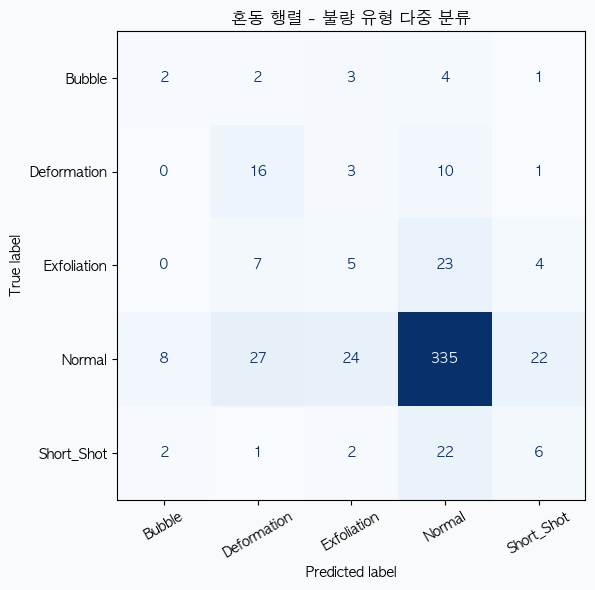

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# =======================================================
# STEP 9. 불량 유형 다중 분류
#
# 타겟: Defect_Type
#   - Normal / Exfoliation / Short_Shot / Deformation / Bubble
#   - Other, Stain 제외 (샘플 수 극소)
# 피처: 기존 21개 공정 피처 동일
# =======================================================

# -------------------------------------------
# 데이터 준비
# -------------------------------------------
type1_multi = pd.read_csv('../../data/df_final_Type1.csv')
type1_multi['Pressure_Diff_ratio'] = type1_multi['Casting_Pressure'] / type1_multi['Cylinder_Pressure']

# Other, Stain 제외
type1_multi = type1_multi[~type1_multi['Defect_Type'].isin(['Other', 'Stain'])].reset_index(drop=True)

X_multi = type1_multi[FEATURES].copy()
y_multi = type1_multi['Defect_Type'].copy()

print("[ 클래스 분포 ]")
print(y_multi.value_counts())
print(f"\n전체 샘플: {len(y_multi)}건")

# -------------------------------------------
# Train/Test Split
# -------------------------------------------
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_multi, y_multi, test_size=0.2, stratify=y_multi, random_state=SEED)

print(f"\n훈련셋: {X_tr_m.shape[0]}행 / 테스트셋: {X_te_m.shape[0]}행")

# -------------------------------------------
# LightGBM 다중 분류
# -------------------------------------------
lgb_multi = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.01, num_leaves=127,
    subsample=0.7, class_weight='balanced',
    random_state=SEED, verbose=-1
)
lgb_multi.fit(X_tr_m, y_tr_m)
y_pred_multi = lgb_multi.predict(X_te_m)

print("\n[ LightGBM 다중 분류 성능 ]")
print(classification_report(y_te_m, y_pred_multi, digits=4))

# -------------------------------------------
# 혼동 행렬 시각화
# -------------------------------------------
labels = sorted(y_multi.unique())
cm_multi = confusion_matrix(y_te_m, y_pred_multi, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#F8FAFB')
ConfusionMatrixDisplay(cm_multi, display_labels=labels).plot(
    ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30)
ax.set_title('혼동 행렬 - 불량 유형 다중 분류', fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 9-1. 불량 유형 다중 분류 — Normal 제외 (불량끼리만)

[ 클래스 분포 (Normal 제외) ]
Defect_Type
Exfoliation    196
Short_Shot     165
Deformation    152
Bubble          58
Name: count, dtype: int64

전체 샘플: 571건
훈련셋: 456행 / 테스트셋: 115행

[ 베이스라인 (SMOTE 없음) ]
              precision    recall  f1-score   support

      Bubble     0.2000    0.2500    0.2222        12
 Deformation     0.4286    0.5806    0.4932        31
 Exfoliation     0.4444    0.4103    0.4267        39
  Short_Shot     0.4545    0.3030    0.3636        33

    accuracy                         0.4087       115
   macro avg     0.3819    0.3860    0.3764       115
weighted avg     0.4176    0.4087    0.4052       115

[ SMOTE 후 클래스 분포 ]
Defect_Type
Exfoliation    157
Bubble         157
Deformation    157
Short_Shot     157
Name: count, dtype: int64

[ SMOTE 적용 후 ]
              precision    recall  f1-score   support

      Bubble     0.1875    0.2500    0.2143        12
 Deformation     0.4444    0.5161    0.4776        31
 Exfoliation     0.5122    0.5385    0.5250        39
  Sh

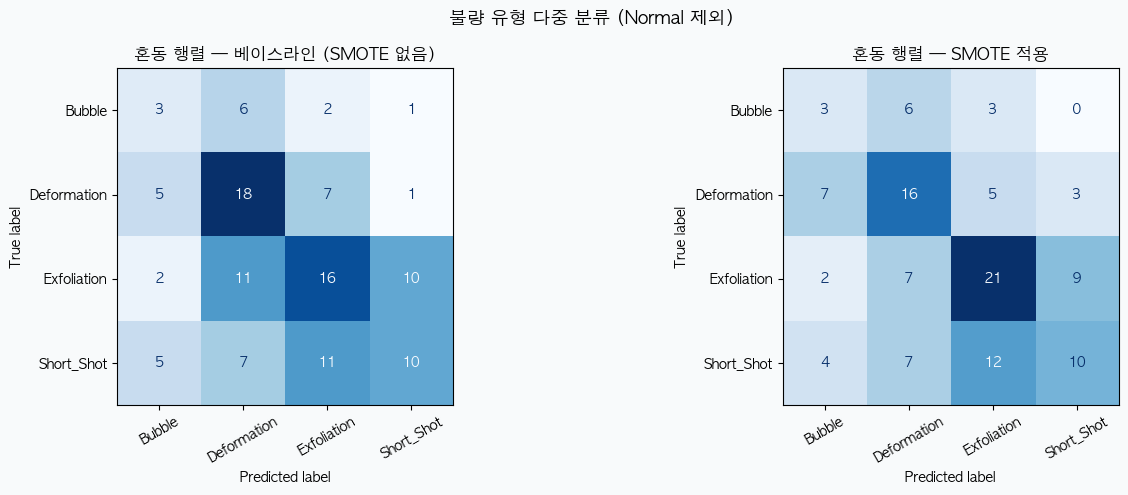

In [14]:
# =======================================================
# STEP 9-1. Normal 제외 — 불량 유형끼리만 분류
#
# STEP 9에서 다중 분류 성능이 낮았던 원인 진단:
# - Normal이 압도적으로 많아(2075건) 모델이 Normal에 편향
# - 진짜 관심사는 "어떤 불량인가" → Normal 제외 후 재시도
# =======================================================

from imblearn.over_sampling import SMOTE

# Normal 제외, 불량 샘플만
type1_defect = type1_multi[type1_multi['Defect_Type'] != 'Normal'].reset_index(drop=True)

X_def = type1_defect[FEATURES].copy()
y_def = type1_defect['Defect_Type'].copy()

print("[ 클래스 분포 (Normal 제외) ]")
print(y_def.value_counts())
print(f"\n전체 샘플: {len(y_def)}건")

# Train/Test Split
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_def, y_def, test_size=0.2, stratify=y_def, random_state=SEED)
print(f"훈련셋: {X_tr_d.shape[0]}행 / 테스트셋: {X_te_d.shape[0]}행")

# -------------------------------------------
# 1. SMOTE 없이 베이스라인
# -------------------------------------------
lgb_def = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.01, num_leaves=63,
    subsample=0.7, class_weight='balanced',
    random_state=SEED, verbose=-1
)
lgb_def.fit(X_tr_d, y_tr_d)
y_pred_def = lgb_def.predict(X_te_d)

print("\n[ 베이스라인 (SMOTE 없음) ]")
print(classification_report(y_te_d, y_pred_def, digits=4))

# -------------------------------------------
# 2. SMOTE 적용
# -------------------------------------------
smote_def = SMOTE(random_state=SEED, k_neighbors=3)
X_tr_d_sm, y_tr_d_sm = smote_def.fit_resample(X_tr_d, y_tr_d)

print("[ SMOTE 후 클래스 분포 ]")
print(pd.Series(y_tr_d_sm).value_counts())

lgb_def_sm = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.01, num_leaves=63,
    subsample=0.7, class_weight='balanced',
    random_state=SEED, verbose=-1
)
lgb_def_sm.fit(X_tr_d_sm, y_tr_d_sm)
y_pred_def_sm = lgb_def_sm.predict(X_te_d)

print("\n[ SMOTE 적용 후 ]")
print(classification_report(y_te_d, y_pred_def_sm, digits=4))

# -------------------------------------------
# 혼동 행렬
# -------------------------------------------
labels_def = sorted(y_def.unique())
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8FAFB')

for ax, y_pred_plot, title in zip(
    axes,
    [y_pred_def, y_pred_def_sm],
    ['베이스라인 (SMOTE 없음)', 'SMOTE 적용']
):
    cm_def = confusion_matrix(y_te_d, y_pred_plot, labels=labels_def)
    ConfusionMatrixDisplay(cm_def, display_labels=labels_def).plot(
        ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30)
    ax.set_title(f'혼동 행렬 — {title}', fontweight='bold')

plt.suptitle('불량 유형 다중 분류 (Normal 제외)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 9 결론 — 불량 유형 분류 한계 및 방향 전환

### 실험 요약

| 실험 | 조건 | macro F1 | 비고 |
|------|------|----------|------|
| STEP 9 | Normal 포함, 5클래스 | 0.338 | Normal만 F1=0.827, 나머지 0.13~0.39 |
| STEP 9-1 (베이스라인) | Normal 제외, 4클래스 | 0.376 | 4클래스 랜덤 기준(0.25) 대비 소폭 상회 |
| STEP 9-1 (SMOTE) | Normal 제외 + SMOTE | 0.395 | 최선의 시도, 실용성 없음 |

### 실패 원인

1. **절대 샘플 수 부족** — Bubble 58건(훈련셋 46건), 테스트셋 12건으로 어떤 모델도 학습 불가
2. **유형간 공정 패턴 유사** — Exfoliation/Short_Shot/Deformation 모두 비슷한 공정 조건에서 발생, 피처로 구분되는 신호 없음
3. **미수집 변수 영향 가능성** — 불량 유형은 금형 상태, 재료 배치, 작업자 등 공정 수치 외 요인에 의존할 가능성

### 방향 전환

불량 유형 분류 대신 아래 두 축으로 목표 재설정:

- **이진 분류 (불량 여부)** — LightGBM, Recall ≥ 0.80 달성 → 실용적 조기 경보 가능
- **SHAP 기반 유형 간접 해석** — Type 1 vs Type 2 중요 변수 비교로 불량 발생 메커니즘 차이 분석

> 공정 데이터만으로 불량 유형을 구분하는 것은 현재 데이터셋의 구조적 한계이며,
> 불량 탐지 자체의 신뢰도(Recall 0.80 이상)를 확보하는 것이 현실적 목표.

In [15]:
#with open('model_type1_lgbm.pkl', 'wb') as f:
    #pickle.dump({'model': best_lgb, 'threshold': float(opt_thr_lgbm), 'features': list(X_train.columns)}, f)

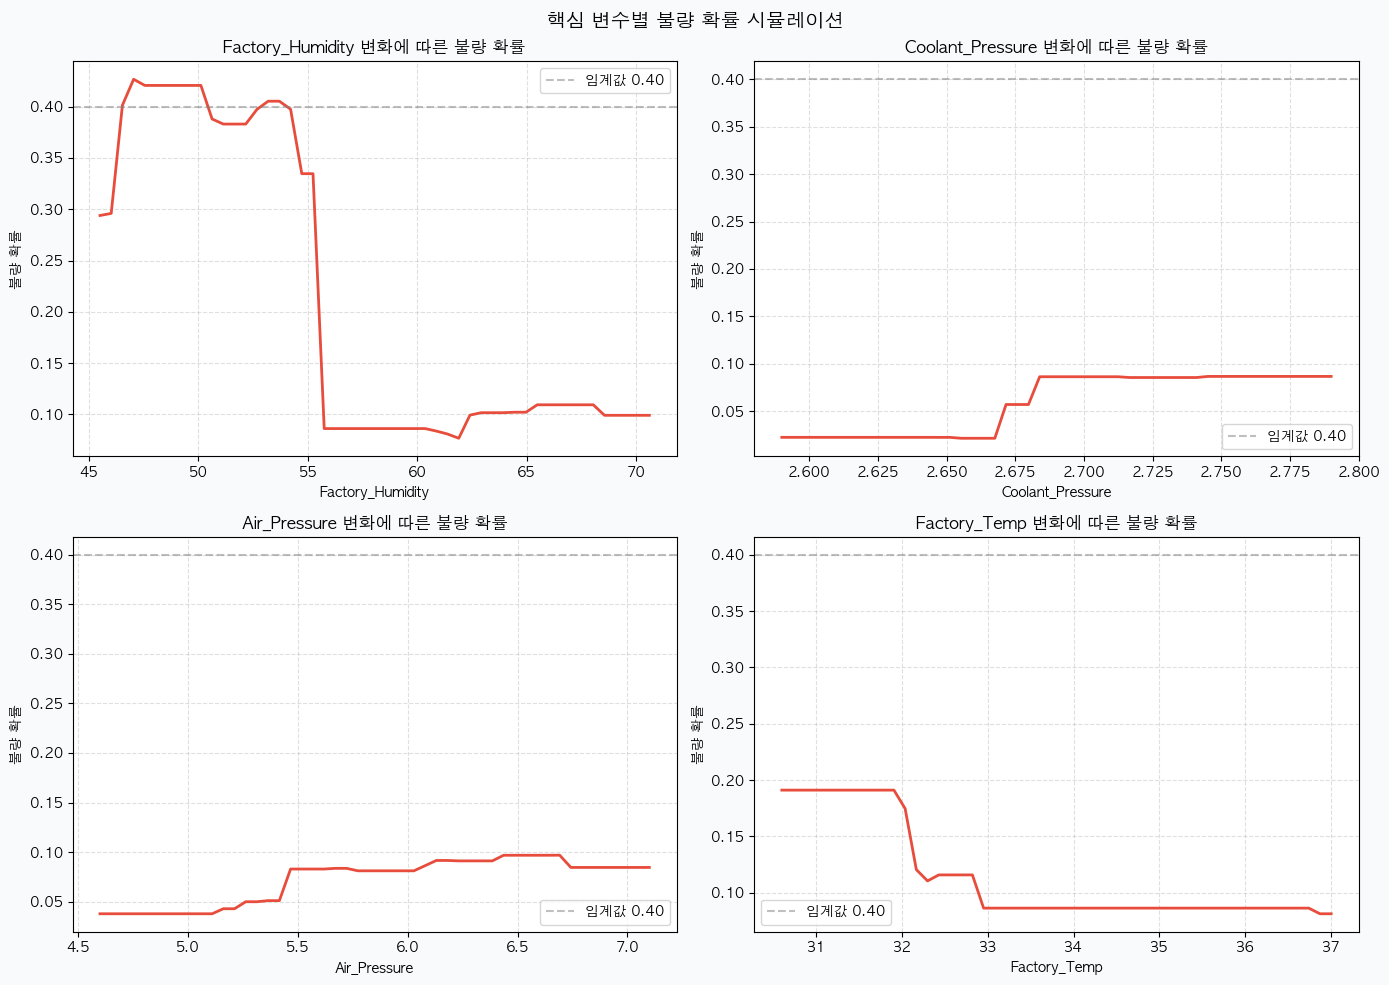

  최적 공정 조건 (불량 확률 하위 10%)
      Factory_Humidity  Coolant_Pressure  Air_Pressure  Factory_Temp    불량확률
mean           63.8976            2.6244        5.8341       33.4049  0.0256
min            57.7000            2.5900        4.6000       31.6000  0.0116
max            70.6000            2.6500        7.1000       35.1000  0.0362

 최적 조건 요약:
  Factory_Humidity: 63.90 (범위 57.70 ~ 70.60)
  Coolant_Pressure: 2.62 (범위 2.59 ~ 2.65)
  Air_Pressure: 5.83 (범위 4.60 ~ 7.10)
  Factory_Temp: 33.40 (범위 31.60 ~ 35.10)


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------
# 기준값: 양품 데이터 평균
# -------------------------------------------
baseline = X_test[y_test == 0].mean().to_dict()

# -------------------------------------------
# 1. 시나리오 시뮬레이션
# 핵심 변수별 구간 변화 → 불량 확률 변화
# -------------------------------------------
key_vars = ['Factory_Humidity', 'Coolant_Pressure', 'Air_Pressure', 'Factory_Temp']

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#F8FAFB')
axes = axes.flatten()

for i, var in enumerate(key_vars):
    probs = []
    var_range = np.linspace(X_test[var].min(), X_test[var].max(), 50)
    
    for val in var_range:
        sample = pd.DataFrame([baseline])
        sample[var] = val
        prob = best_lgb.predict_proba(sample)[:,1][0]
        probs.append(prob)
    
    axes[i].plot(var_range, probs, color='#E74C3C', lw=2)
    axes[i].axhline(0.4, color='gray', linestyle='--', alpha=0.5, label='임계값 0.40')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('불량 확률')
    axes[i].set_title(f'{var} 변화에 따른 불량 확률', fontweight='bold')
    axes[i].legend()
    axes[i].grid(linestyle='--', alpha=0.4)

plt.suptitle('핵심 변수별 불량 확률 시뮬레이션', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------------------
# 2. 최적 공정 조건 탐색
# 양품 데이터 중 불량 확률 최저 구간 추출
# -------------------------------------------
normal_data = X_test[y_test == 0].copy()
normal_data['불량확률'] = best_lgb.predict_proba(normal_data)[:,1]
normal_data = normal_data.sort_values('불량확률')

print("=" * 55)
print("  최적 공정 조건 (불량 확률 하위 10%)")
print("=" * 55)
top10 = normal_data.head(int(len(normal_data) * 0.1))
optimal = top10[key_vars + ['불량확률']].describe().loc[['mean', 'min', 'max']]
print(optimal.round(4))

print("\n 최적 조건 요약:")
for var in key_vars:
    print(f"  {var}: {top10[var].mean():.2f} (범위 {top10[var].min():.2f} ~ {top10[var].max():.2f})")